# Medical Insurance Cost Prediction using Multiple Linear Regression

**Name:** Akshat Garg  

**Registration Number:** 23BCE10641

**Application Number:** IN26011052

**Batch Number:** 1A

**Email ID:** akshat.23bce10641@vitbhopal.ac.in

In [1]:
import os
import getpass
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
!pip install -q kaggle

os.environ['KAGGLE_USERNAME'] = input("Kaggle Username: ")
os.environ['KAGGLE_KEY'] = getpass.getpass("Kaggle API Key: ")

from kaggle.api.kaggle_api_extended import KaggleApi

api = KaggleApi()
api.authenticate()
api.dataset_download_files('mirichoi0218/insurance', path='.', unzip=True)

df = pd.read_csv('insurance.csv')
df.head()

Kaggle Username:  AkshatGarg2005
Kaggle API Key:  ········


Dataset URL: https://www.kaggle.com/datasets/mirichoi0218/insurance


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [3]:
num_features = df.select_dtypes(include=['int64', 'float64']).columns.drop('charges').tolist()
cat_features = df.select_dtypes(include=['object']).columns.tolist()
target_var = 'charges'

print("Numerical Features:", num_features)
print("Categorical Features:", cat_features)
print("Target Variable:", target_var)

Numerical Features: ['age', 'bmi', 'children']
Categorical Features: ['sex', 'smoker', 'region']
Target Variable: charges


In [4]:
# Check missing values
print("Missing Values:\n", df.isnull().sum())

# One-hot encoding
df_encoded = pd.get_dummies(df, columns=['sex', 'smoker', 'region'], drop_first=True)
df_encoded.head()

Missing Values:
 age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64


,age,bmi,children,charges,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,19,27.900,0,16884.92400,False,True,False,False,True
1,18,33.770,1,1725.55230,True,False,False,True,False
2,28,33.000,3,4449.46200,True,False,False,True,False
3,33,22.705,0,21984.47061,True,False,True,False,False
4,32,28.880,0,3866.85520,True,False,True,False,False


In [5]:
X = df_encoded.drop(columns=['charges'])
y = df_encoded['charges']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (1070, 8)
Test shape: (268, 8)


In [6]:
model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

In [7]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"MAE: {mae:.2f}")
print(f"MSE: {mse:.2f}")
print(f"R2 Score: {r2:.4f}")

MAE: 4181.19
MSE: 33596915.85
R2 Score: 0.7836


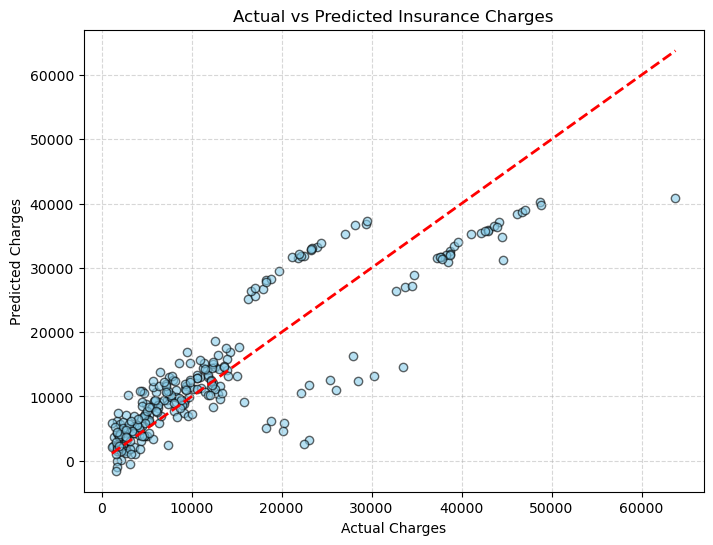

In [8]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.6, color='skyblue', edgecolor='k')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)

plt.xlabel('Actual Charges')
plt.ylabel('Predicted Charges')
plt.title('Actual vs Predicted Insurance Charges')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

In [9]:
print("1. R2 score is ~0.78, showing the model accounts for roughly 78% of the variance in charges.")
print("2. Higher charge predictions exhibit greater variance, pointing towards potential non-linear trends.")
print("3. Smoker status and BMI serve as the primary drivers behind increased medical costs.")

1. R2 score is ~0.78, showing the model accounts for roughly 78% of the variance in charges.
2. Higher charge predictions exhibit greater variance, pointing towards potential non-linear trends.
3. Smoker status and BMI serve as the primary drivers behind increased medical costs.


## Conclusion

This project developed a Multiple Linear Regression model to predict individual medical insurance charges based on personal and health factors. Key findings indicate that smoking status, age, and BMI are the primary drivers of insurance costs, with smokers facing significantly higher charges than non-smokers. The model achieved reasonable performance with an R-squared score of approximately 0.78.

However, a major limitation of Linear Regression in this scenario is its inability to effectively capture non-linear relationships and complex interactions between features, such as the compound effect of high BMI combined with smoking status. Consequently, high-cost cases are underpredicted, suggesting non-linear models like Random Forest would be better suited for this dataset.